# Quickstart: Spectral Solar

Basic usage example demonstrating spectral radiative transfer from 400nm to 700nm simulations with xarray integration.

In [1]:

# Import PyRadtran components using NEW IO system
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd
from matplotlib import cm


# Load the configuration from the YAML file
config_path = Path('../config/spectral_config.yaml')
import logging
# change to "DEBUG" if you want to see more output
logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

N_timesteps = 10

# stationary simulation at constant altitude, latitude, and longitude but with varying time
ds = xr.Dataset(
    coords={
        'time' : pd.date_range('2025-04-04T08:00:00', periods=N_timesteps, freq='h'),
        'latitude' : ('time', [61.0] * N_timesteps),
        'longitude' : ('time', [22.0] * N_timesteps),
        'altitude' : ('altitude', [0, 1, 5, 10, 25, 50, 100]),
    }
)

# Run a spectral simulation for a single point using NEW IO system
ds_sim = ds.pyradtran.run(
    config_path=config_path,
    return_dataset=True,
    save_to_file=True,
)

print("\nSimulation complete with NEW IO system!")
print(f"Dataset variables: {list(ds_sim.data_vars.keys())}")
print(f"Dataset coordinates: {list(ds_sim.coords.keys())}")
print(f"Dataset shape: {ds_sim.dims}")

Running simulations: 100%|██████████| 10/10 [00:45<00:00,  4.60s/sim, Success=10, Total=10]



Simulation complete with NEW IO system!
Dataset variables: ['zout', 'lambda', 'sza', 'edir', 'eglo', 'edn', 'eup', 'enet', 'albedo']
Dataset coordinates: ['time', 'wavelength', 'altitude']
Dataset shape: FrozenMappingWarningOnValuesAccess({'time': 10, 'wavelength': 301, 'altitude': 7})


In [5]:
ds_sim

<xarray.Dataset> Size: 2MB
Dimensions:     (time: 10, wavelength: 301, altitude: 7)
Coordinates:
  * time        (time) datetime64[ns] 80B 2025-04-04T08:00:00 ... 2025-04-04T...
  * wavelength  (wavelength) float64 2kB 400.0 401.0 402.0 ... 698.0 699.0 700.0
  * altitude    (altitude) float64 56B 0.0 1.0 5.0 10.0 25.0 50.0 100.0
Data variables:
    zout        (wavelength, altitude, time) float64 169kB 0.0 0.0 ... 100.0
    lambda      (wavelength, altitude, time) float64 169kB 400.0 400.0 ... 700.0
    sza         (wavelength, altitude, time) float64 169kB 62.63 58.42 ... 88.83
    edir        (wavelength, altitude, time) float64 169kB 362.7 454.6 ... 28.84
    eglo        (wavelength, altitude, time) float64 169kB 569.7 671.6 ... 28.84
    edn         (wavelength, altitude, time) float64 169kB 207.0 ... 1.078e-05
    eup         (wavelength, altitude, time) float64 169kB 2.079e-12 ... 8.253
    enet        (wavelength, altitude, time) float64 169kB 569.7 671.6 ... 20.59
    albedo      (wavelength, altitude, time) float64 169kB 3.65e-15 ... 0.2862
Attributes: (12/24)
    point_id:                      20250404_080000_61.00_22.00_0
    time:                          2025-04-04T08:00:00
    latitude:                      61.0
    longitude:                     22.0
    generated_by:                  pyradtran
    pyradtran_version:             unified_system
    ...                            ...
    config_integrate_wavelength:   0
    config_output_altitudes_km:    [0.0, 1.0, 5.0, 10.0, 25.0, 50.0, 100.0]
    config_libradtran_bin:         /opt/libradtran/2.0.4/bin/uvspec
    config_libradtran_data:        /opt/libradtran/2.0.4/share/libRadtran/data
    config_max_workers:            1
    config_timeout_seconds:        60

In [11]:
X.shape, Y.shape, z.shape

((7, 10), (7, 10), (10, 7))

## Sanity Check


<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
/projekt_agmwend/home_rad/Joshua/tmp/ipykernel_1752643/1171289052.py:19: SyntaxWarning: invalid escape sequence '\m'
  ax.set_zlabel('$F_\mathrm{dir}^\downarrow$ ($\mathrm{W \cdot m^{-2}}$)')


Text(0.5, 0, '$F_\\mathrm{dir}^\\downarrow$ ($\\mathrm{W \\cdot m^{-2}}$)')

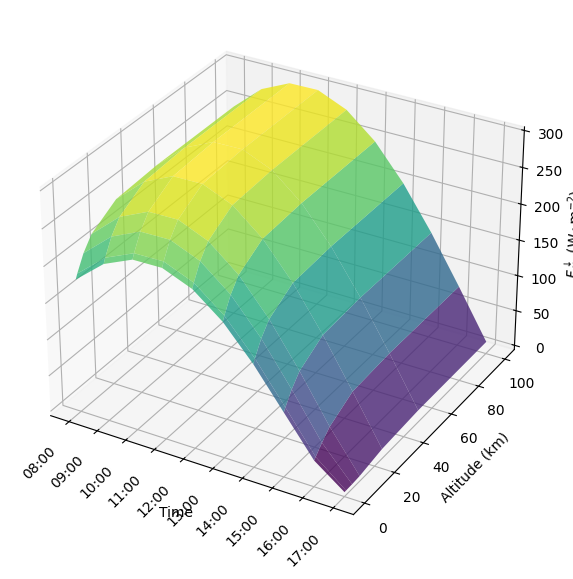

In [12]:
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': '3d'})

ax.set_prop_cycle(
    color=cm.viridis(np.linspace(0, 1, len(ds_sim['time'].values))),
)

# make a 3d plot with time on the x-axis, wavelength on the y-axis, and irradiance on the z-axis
x = np.arange(len(ds_sim['time'].values))
y = ds_sim['altitude'].values
z = ds_sim.integrate('wavelength')['edir'] / 1000
X, Y = np.meshgrid(x, y)
ax.plot_surface(X, Y, z, cmap=cm.viridis, edgecolor='none', alpha=0.8)
# format x-axis as time
ax.set_xticks(x)
ax.set_xticklabels(ds_sim['time'].dt.strftime('%H:%M').values, rotation=45, ha='right')

ax.set_xlabel('Time')
ax.set_ylabel('Altitude (km)')
ax.set_zlabel('$F_\mathrm{dir}^\downarrow$ ($\mathrm{W \cdot m^{-2}}$)')


In [ ]:
ds_sim

<xarray.Dataset> Size: 2MB
Dimensions:     (time: 10, wavelength: 301, altitude: 7, latitude: 10,
                 longitude: 10)
Coordinates:
  * time        (time) datetime64[ns] 80B 2025-04-04T08:00:00 ... 2025-04-04T...
  * latitude    (latitude) float64 80B 61.0 61.0 61.0 61.0 ... 61.0 61.0 61.0
  * longitude   (longitude) float64 80B 22.0 22.0 22.0 22.0 ... 22.0 22.0 22.0
  * altitude    (altitude) float64 56B 0.0 1.0 5.0 10.0 25.0 50.0 100.0
  * wavelength  (wavelength) float64 2kB 400.0 401.0 402.0 ... 698.0 699.0 700.0
Data variables:
    zout        (time, wavelength, altitude) float64 169kB 0.0 1.0 ... 100.0
    lambda      (time, wavelength, altitude) float64 169kB 400.0 400.0 ... 700.0
    sza         (time, wavelength, altitude) float64 169kB 62.63 62.63 ... 88.83
    edir        (time, wavelength, altitude) float64 169kB 362.7 399.6 ... 28.84
    eglo        (time, wavelength, altitude) float64 169kB 613.1 636.3 ... 28.84
    edn         (time, wavelength, altitude) float64 169kB 250.4 ... 1.085e-05
    eup         (time, wavelength, altitude) float64 169kB 183.9 207.1 ... 12.07
    enet        (time, wavelength, altitude) float64 169kB 429.2 429.2 ... 16.78
    albedo      (time, wavelength, altitude) float64 169kB 0.3 0.3254 ... 0.4184
Attributes: (12/25)
    point_id:                      20250404_080000_61.00_22.00
    time:                          2025-04-04T08:00:00
    latitude:                      61.0
    longitude:                     22.0
    generated_by:                  pyradtran
    pyradtran_version:             unified_system
    ...                            ...
    config_integrate_wavelength:   0
    config_output_altitudes_km:    [0.0, 1.0, 5.0, 10.0, 25.0, 50.0, 100.0]
    config_libradtran_bin:         /opt/libradtran/2.0.4/bin/uvspec
    config_libradtran_data:        /opt/libradtran/2.0.4/share/libRadtran/data
    config_max_workers:            1
    config_timeout_seconds:        60

## Results

Visualization of spectral direct irradiance across wavelength at the surface.

<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
/projekt_agmwend/home_rad/Joshua/tmp/ipykernel_3645427/4243175334.py:17: SyntaxWarning: invalid escape sequence '\m'
  ax.set_zlabel('$F_\mathrm{dir}^\downarrow$ ($\mathrm{W m^{-2}}$)')


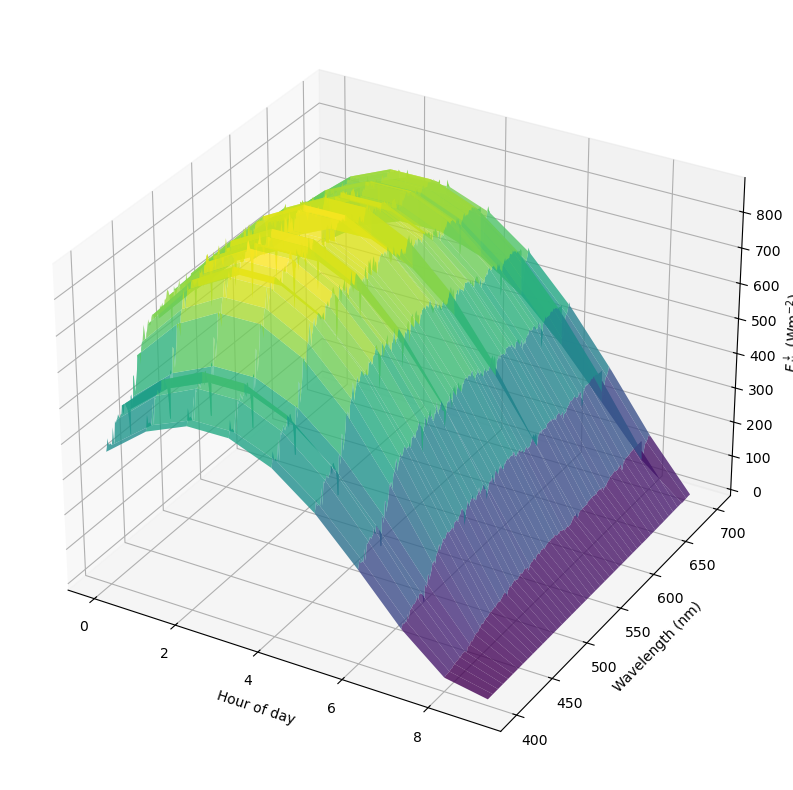

In [ ]:

# make a 3d plot with time on the x-axis, wavelength on the y-axis, and irradiance on the z-axis
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.set_prop_cycle(
    color=cm.viridis(np.linspace(0, 1, len(ds_sim['wavelength'].values))),
)

x = np.arange(len(ds_sim['time'].values))
y = ds_sim['wavelength'].values
z = ds_sim.sel(altitude=0)['edir'].values.T
X, Y = np.meshgrid(x, y)

ax.plot_surface(X, Y, z, cmap=cm.viridis, edgecolor='none', alpha=0.8)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Wavelength (nm)')
ax.set_zlabel('$F_\mathrm{dir}^\downarrow$ ($\mathrm{W m^{-2}}$)')

plt.tight_layout()

## Spectral Simulation for single altitude and single timestep

Here, we visualize the spectral direct irradiance at the surface for a single altitude and single timestep and show the different simulation outputs.

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
/projekt_agmwend/home_rad/Joshua/tmp/ipykernel_3645427/1716632304.py:8: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('$F_\mathrm{dir}^\downarrow$ ($\mathrm{W m^{-2}}$)')


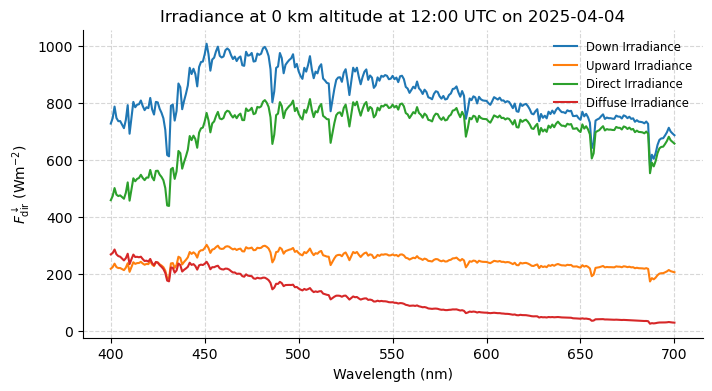

In [ ]:
fig, ax= plt.subplots(figsize=(8, 4))

ds_sim.sel(altitude=0, time='2025-04-04T12:00:00')['eglo'].plot(ax=ax, label='Down Irradiance')
ds_sim.sel(altitude=0, time='2025-04-04T12:00:00')['eup'].plot(ax=ax, label='Upward Irradiance')
ds_sim.sel(altitude=0, time='2025-04-04T12:00:00')['edir'].plot(ax=ax, label='Direct Irradiance')
ds_sim.sel(altitude=0, time='2025-04-04T12:00:00')['edn'].plot(ax=ax, label='Diffuse Irradiance')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('$F_\mathrm{dir}^\downarrow$ ($\mathrm{W m^{-2}}$)')
ax.set_title('Irradiance at 0 km altitude at 12:00 UTC on 2025-04-04')

ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(frameon=False, loc='upper right', fontsize='small')
